### SEA4001W: Advanced Python Applications: P3: Using Cartopy for Mapping
MNKREB002 Rebecca Monk - 14 March 2026

#### Set-Up
import the packages needed and set the working directory

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy

from geopy.geocoders import Nominatim
from geopy.distance import geodesic

os.chdir("/Users/rebeccamonk/Desktop/MNKREB002-SCDM2026/P3/")

#### Part 1: The Antarctic Continent and the Southern Ocean

- the South Polar Stereographic Projection is used to show Antarctica with a set of axes
- the Plate Carree Coordinate System is used for map extents and the gridlines

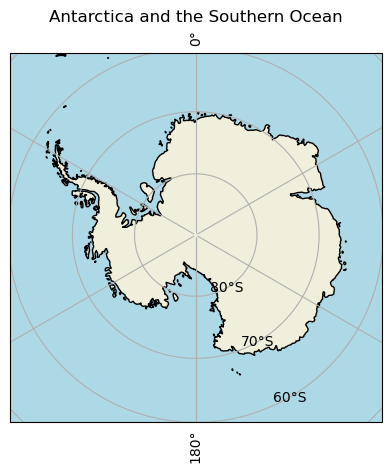

In [2]:
# Define the projections that will be used:
ccrs.SouthPolarStereo(central_longitude=0.0, true_scale_latitude=None, globe=None)
ccrs.PlateCarree(central_longitude=0.0, globe=None)
plt.figure() # this opens a window to plot the figure
ax = plt.axes(projection=ccrs.SouthPolarStereo())

# Define the extent and set the extent limits of the map with the Place Carree Coordinate System
extent = [-180, 180, -90, -60]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True)

# Add features to the map
ax.add_feature(cartopy.feature.LAND)
ax.add_feature(cartopy.feature.OCEAN, facecolor="lightblue")
ax.coastlines()

# Add a title
plt.title("Antarctica and the Southern Ocean")
plt.show()

Figure 1: The South Polar Stereographic Projection was chosen for this map as it shows Antarctica in the centre with the Southern Ocean surrounding it. The size and shape of Antarctica is preserved and it has not been broken. This projection also covers latitudes higher than 80ºS which other projections (the Mercator Projections) cannot do. 

#### Part 2: The South Atlantic Ocean

- the Equidistant Conic Projection is used to show the South Atlantic with a set of axes
- the Plate Carree Coordinate System is used for map extents and the gridlines

[Location(Cape Town, City of Cape Town, Western Cape, 8001, South Africa, (-33.9288301, 18.4172197, 0.0)), Location(Walvis Bay, Erongo Region, 13013, Namibia, (-22.9557607, 14.5071125, 0.0)), Location(Rio de Janeiro, Região Geográfica Imediata do Rio de Janeiro, Região Metropolitana do Rio de Janeiro, Região Geográfica Intermediária do Rio de Janeiro, Rio de Janeiro, Southeast Region, Brazil, (-22.9110137, -43.2093727, 0.0)), Location(Montevideo, Uruguay, (-34.9058916, -56.1913095, 0.0))]
The distance between Cape Town and Montevideo is  6686.227920026834  km
The distance between Wavlis Bay and Rio de Janeiro is  5878.645631799217  km


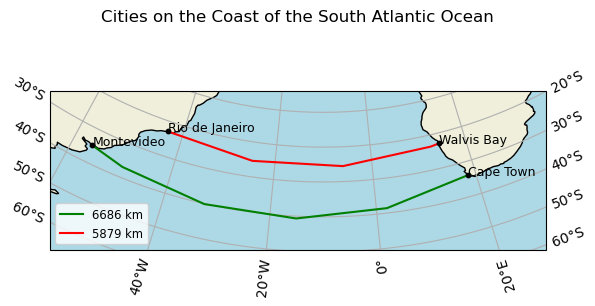

In [3]:
# Define the projections that will be used
ccrs.EquidistantConic(central_longitude=0.0, central_latitude=-30.0, false_easting=0.0, false_northing=0.0, standard_parallels=(-20.0, -50.0), globe=None)
ccrs.PlateCarree(central_longitude=0.0, globe=None)
plt.figure()
ax = plt.axes(projection=ccrs.EquidistantConic(central_longitude=-10, central_latitude=-35))

# Define the extent and set the extent limits of the map with the Place Carree Coordinate System
extent = [-60, 30, -50, -20]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True)
gl.right_labels = True
gl.top_labels = False

# Add features to the map
ax.coastlines()
ax.add_feature(cartopy.feature.LAND)
ax.add_feature(cartopy.feature.OCEAN, facecolor="lightblue")

# Add the locations with their names as labels and with markers
geolocator = Nominatim(user_agent='educational')
place = ['Cape Town','Walvis Bay','Rio de Janeiro','Montevideo']
address = []
for p in place:
    loc = geolocator.geocode(p,language="en")
    address.append(loc)
print(address)

for p in range(len(place)):
    ax.text(address[p].longitude, address[p].latitude,place[p], transform=ccrs.Geodetic(), rotation=0, fontsize=9, color='black')
    ax.scatter(address[p].longitude, address[p].latitude, transform=ccrs.Geodetic(), marker='o', color='black', s=10, zorder=5)

# Add a title and axis labels
ax.set_title("Cities on the Coast of the South Atlantic Ocean", pad=50)

# Calculate the distances
CT = geolocator.geocode('Cape Town')
MV = geolocator.geocode('Montevideo')
RJ = geolocator.geocode('Rio de Janeiro')
WB = geolocator.geocode('Walvis Bay')
print("The distance between Cape Town and Montevideo is ", geodesic(CT.point, MV.point).km," km")
print("The distance between Wavlis Bay and Rio de Janeiro is ", geodesic(WB.point, RJ.point).km," km")

# Add greate circles to display the distances
longitude1 = CT.longitude, MV.longitude
latitude1 = CT.latitude, MV.latitude
ax.plot(longitude1, latitude1, transform=ccrs.Geodetic(), label='6686 km', color='green')

longitude2 = RJ.longitude, WB.longitude
latitude2 = RJ.latitude, WB.latitude
ax.plot(longitude2, latitude2, transform=ccrs.Geodetic(), label='5879 km', color='red')

# Add a legend
plt.legend(fontsize='small', loc="lower left")

Figure 2: The Equidistant Conic Projection was chosen for this map as it preserves the distance between the four locations. It was assumed that this map should be produced in order to show the distance and compare the distances between locations on the coast of the South Atlantic Ocean as these locations share similar latitudes and longitudes. This is why the distances acorss the South Atlantic Ocean have also been calcuated and displayed. This projection is generally used to map the mid-latitude regions with a large east-west and the South Atlantic Ocean falls into this category.

#### Part 3: False Bay Resolution Maps

- the Plate Carree Projection and Coordinate System is used

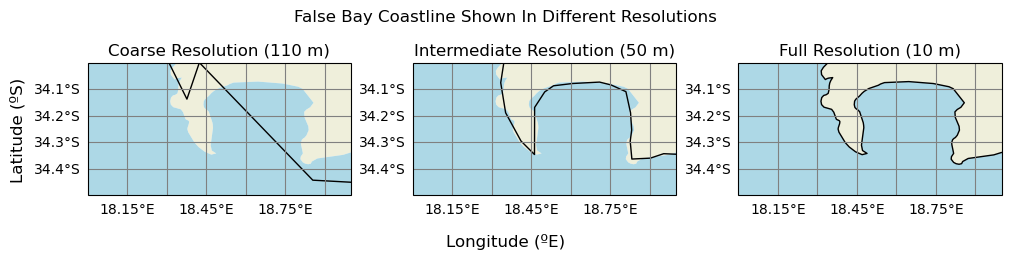

In [4]:
ccrs.PlateCarree(central_longitude=0.0, globe=None)

# Set the map extent 
extent = [18, 19, -34.5, -34]

# Create the coastline resolutions
resolutions = ['110m', '50m', '10m']
titles = ["Coarse Resolution (110 m)", "Intermediate Resolution (50 m)", "Full Resolution (10 m)"]

# Create the figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(10,6), subplot_kw={'projection':ccrs.PlateCarree()}, constrained_layout=True)

# Set the extent and add the coastlines and gridlines with labels in a loop
for i, ax in enumerate(axes):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution=resolutions[i])
    gl = ax.gridlines(draw_labels=True, color="gray")
    gl.top_labels = False
    gl.right_labels = False
        
    ax.set_title(titles[i])
    
    # overlay the land and ocean features
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.OCEAN, facecolor="lightblue")
    
# Add a figure title and axis labels
fig.suptitle("False Bay Coastline Shown In Different Resolutions", y=0.7)
fig.supxlabel("Longitude (ºE)", y=0.3)
fig.supylabel("Latitude (ºS)")

plt.show()

Figure 3: The Plate Carree Projection was used for this map as it good for mapping small areas as it has no satellite height or equator restrictions (the Geostationary and Mercator Projections were also used but failed to produce the maps due to the restructions mentioned). However, the shape, scale and area of False Bay has been distorted due to this projection. 

Figure 3 shows the difference between different resolutions when looking at a small bay. The different coastlines have been created with the different resolutions (shown in black) and this can be compared to the Cartopy Land Feature which also maps the coastlines (shown in beige). It is clear that the Cartopy Land Feature makes use of the Full Resolution from the GSHHG Database as the outline of the coast is aligned with the outline of the land. 